### Occlusion Score Estimation via Dual-Model Confidence Gap

Оба варианта измеряют разницу между предсказаниями тяжелой модели (B5) и лекой модели (B0), но используют разные проекции распределения вероятностей.

#### 1. Вариант А: Max Confidence Gap (Разница индивидуальных максимумов)
Сравнивает пиковую уверенность каждой модели в её собственном выбранном классе:
$$\Delta_A(x, y) = \max_c P_{B5}(c \mid x, y) - \max_c P_{B0}(c \mid x, y)$$

* **Особенность:** Не учитывает, совпали ли классы у моделей. Оценивает общий разрыв в определенности сетей.

#### 2. Вариант Б: Strong-Guided Confidence Gap (Разница на целевом классе B5)

Берет класс $c^*$, выбранный моделью $\text{B5}$, и сравнивает вероятности обеих сетей строго на этом классе:
$$c^*(x, y) = \arg\max_c P_{B5}(c \mid x, y)$$
$$\Delta_B(x, y) = P_{B5}(c^* \mid x, y) - P_{B0}(c^* \mid x, y)$$
* **Особенность:** Фиксирует расхождение сетей во мнении относительно конкретного класса.

#### Итоговый скор изображения:
$$\text{Score} = \frac{1}{H \cdot W} \sum_{x, y} \Delta(x, y)$$

In [7]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor

warnings.filterwarnings('ignore')

DATA_PATH = Path('/kaggle/input/datasets/mishasavinov/occlusion-dataset')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

DEVICE

device(type='cuda')

In [8]:
class DualModelOcclusionDataset(Dataset):
    def __init__(self, root_dir, processor_b0, processor_b5):
        self.root_dir = Path(root_dir)
        self.processor_b0 = processor_b0
        self.processor_b5 = processor_b5
        self.samples = []

        for p in self.root_dir.rglob('*'):
            if p.is_file() and p.suffix.lower() in ['.png', '.jpg', '.jpeg']:
                parts_lower = [part.lower() for part in p.parts]
                if any(x in parts_lower for x in ['clean', 'clear']):
                    continue
                rel_path = p.relative_to(self.root_dir)
                self.samples.append((p, str(rel_path)))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, rel_path = self.samples[idx]
        image = Image.open(img_path).convert('RGB')

        inputs_b0 = self.processor_b0(images=image, return_tensors='pt')['pixel_values'].squeeze(0)
        inputs_b5 = self.processor_b5(images=image, return_tensors='pt')['pixel_values'].squeeze(0)

        return {
            'pixel_values_b0': inputs_b0,
            'pixel_values_b5': inputs_b5,
            'rel_path': rel_path
        }

In [9]:
from transformers.utils import logging as tf_logging
from huggingface_hub.utils import disable_progress_bars

tf_logging.set_verbosity_error()
disable_progress_bars()

checkpoint_b0 = 'nvidia/segformer-b0-finetuned-cityscapes-768-768'
checkpoint_b5 = 'nvidia/segformer-b5-finetuned-cityscapes-1024-1024'

processor_b0 = SegformerImageProcessor.from_pretrained(
    checkpoint_b0,
    do_resize=True,
    size={'height': 512, 'width': 512}
)

processor_b5 = SegformerImageProcessor.from_pretrained(
    checkpoint_b5,
    do_resize=True,
    size={'height': 512, 'width': 512}
)

model_b0 = SegformerForSemanticSegmentation.from_pretrained(checkpoint_b0).to(DEVICE).eval()
model_b5 = SegformerForSemanticSegmentation.from_pretrained(checkpoint_b5).to(DEVICE).eval()

dataset = DualModelOcclusionDataset(DATA_PATH, processor_b0, processor_b5)
dataloader = DataLoader(dataset, batch_size=8, shuffle=False, num_workers=2)

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1172 [00:00<?, ?it/s]

In [10]:
results = []

with torch.no_grad():
    for batch in tqdm(dataloader):
        pv_b0 = batch['pixel_values_b0'].to(DEVICE)
        pv_b5 = batch['pixel_values_b5'].to(DEVICE)
        rel_paths = batch['rel_path']

        logits_b0 = model_b0(pixel_values=pv_b0).logits
        logits_b5 = model_b5(pixel_values=pv_b5).logits

        logits_b0 = F.interpolate(logits_b0, size=(512, 512), mode='bilinear', align_corners=False)
        logits_b5 = F.interpolate(logits_b5, size=(512, 512), mode='bilinear', align_corners=False)

        probs_b0 = F.softmax(logits_b0, dim=1)
        probs_b5 = F.softmax(logits_b5, dim=1)

        conf_max_b0 = torch.max(probs_b0, dim=1)[0]
        conf_max_b5 = torch.max(probs_b5, dim=1)[0]
        scores_var_a = (conf_max_b5 - conf_max_b0).mean(dim=[1, 2]).cpu().tolist()

        class_b5 = torch.argmax(probs_b5, dim=1, keepdim=True)
        prob_b0_on_b5 = torch.gather(probs_b0, dim=1, index=class_b5).squeeze(1)
        prob_b5_on_b5 = torch.gather(probs_b5, dim=1, index=class_b5).squeeze(1)
        scores_var_b = (prob_b5_on_b5 - prob_b0_on_b5).mean(dim=[1, 2]).cpu().tolist()

        for path, s_a, s_b in zip(rel_paths, scores_var_a, scores_var_b):
            results.append({
                'image_path': path,
                'occlusion_score_var_a': s_a,
                'occlusion_score_var_b': s_b
            })

100%|██████████| 1292/1292 [19:43<00:00,  1.09it/s]


In [11]:
df_scores = pd.DataFrame(results)
df_scores.to_csv('occlusion_scores.csv', index=False)
df_scores.head()

,image_path,occlusion_score_var_a,occlusion_score_var_b
0,Snowflakes/test/cadc__2018_03_06_0008__ca05e22...,0.114628,0.192495
1,Snowflakes/test/cadc__2018_03_06_0008__2b0d042...,0.115689,0.238033
2,Snowflakes/test/cadc__2018_03_06_0008__45a7723...,0.101138,0.233581
3,Snowflakes/test/cadc__2018_03_06_0008__ebf56c7...,0.075957,0.153054
4,Snowflakes/test/cadc__2018_03_06_0008__ccdd461...,0.089808,0.173889


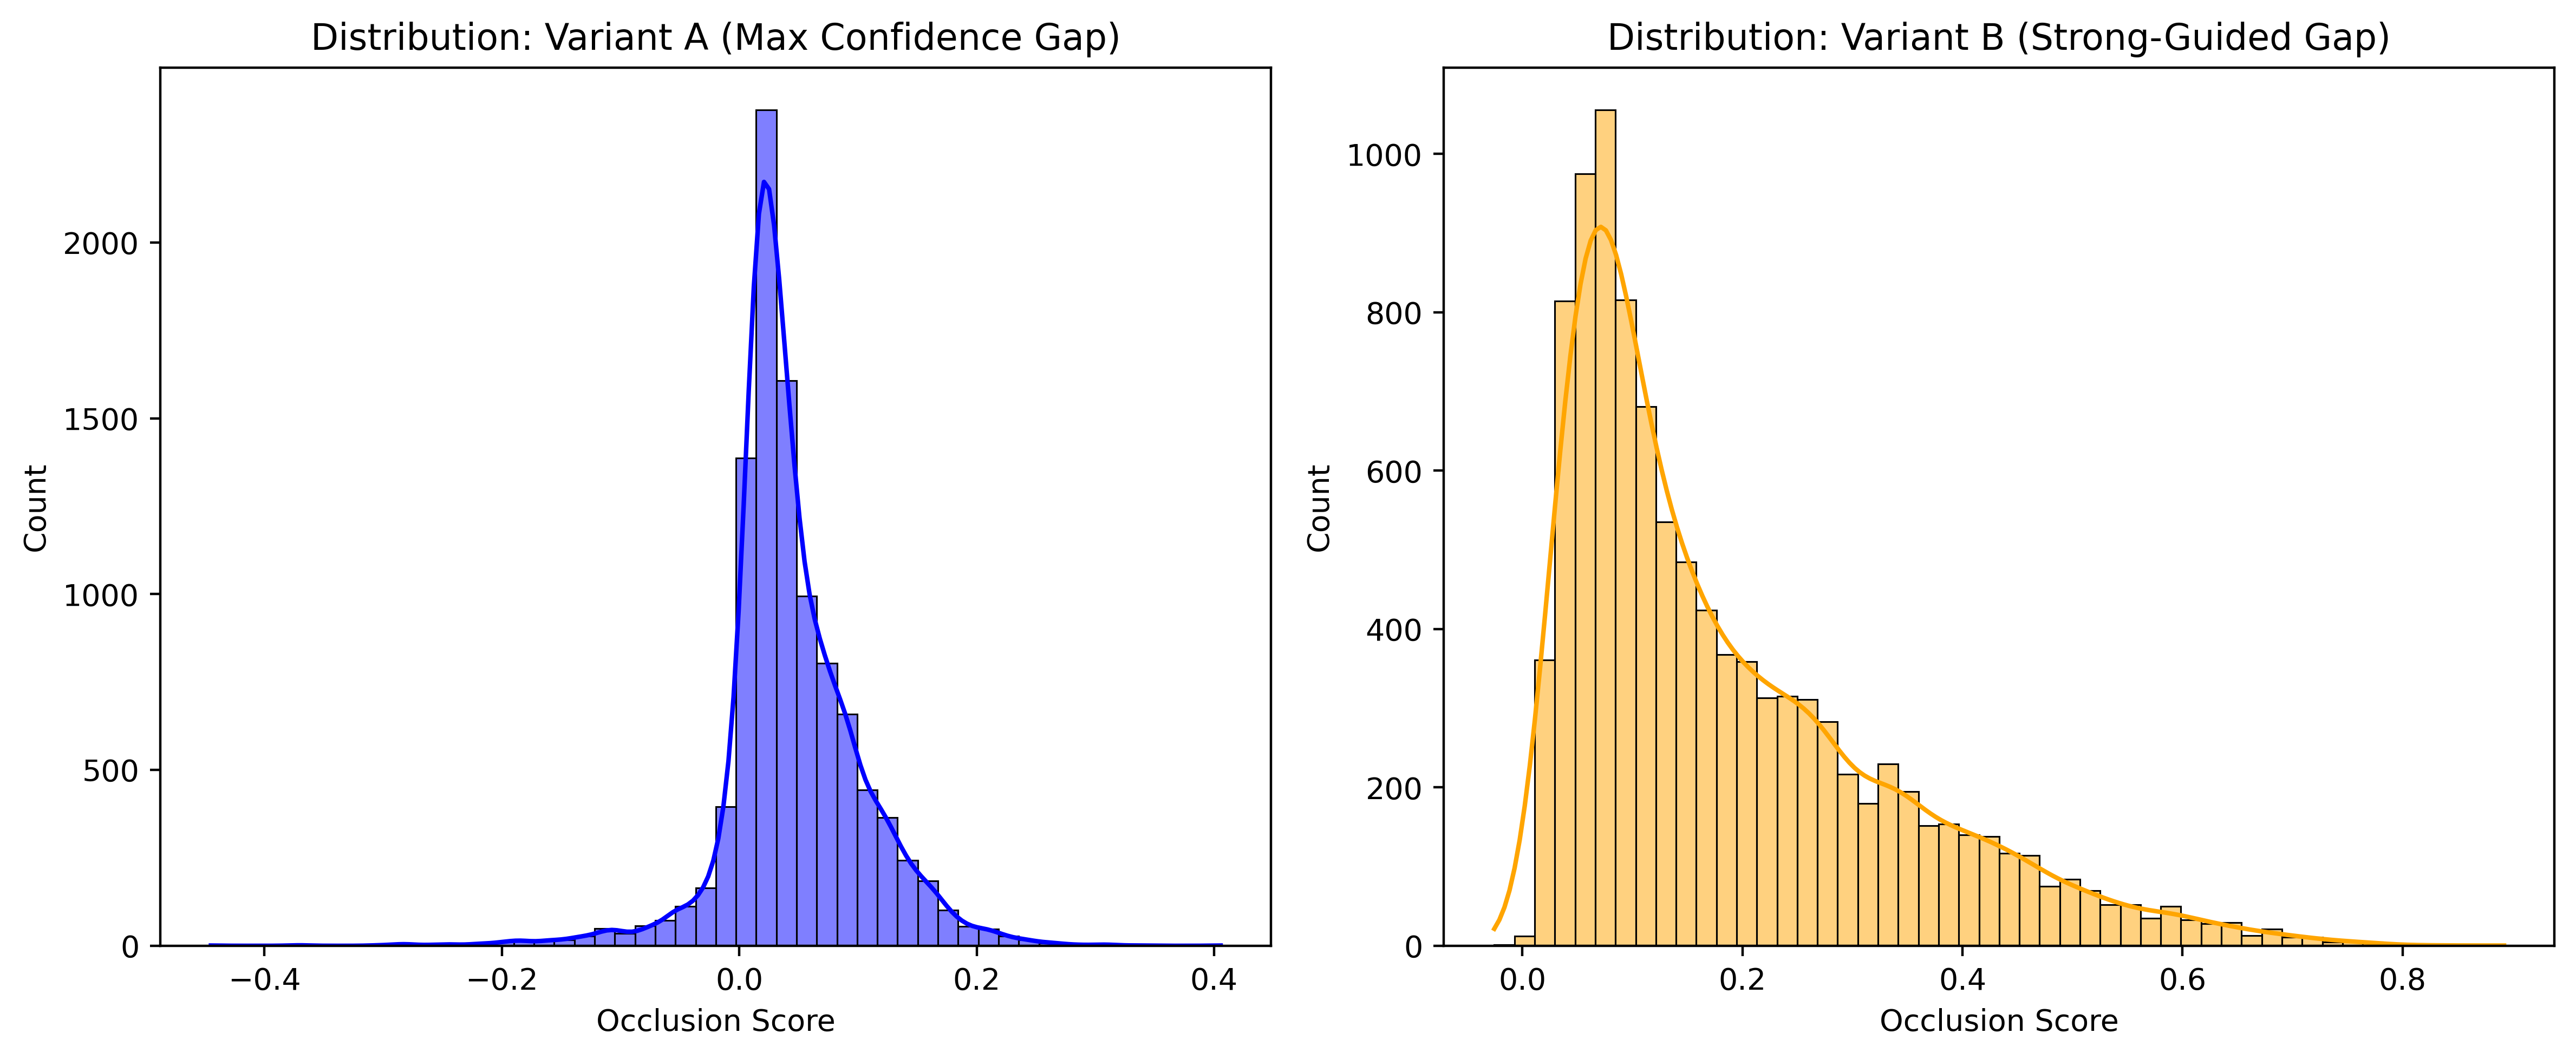

Статистика по скорам:
       occlusion_score_var_a  occlusion_score_var_b
count           10329.000000           10329.000000
mean                0.044707               0.185484
std                 0.057292               0.146088
min                -0.445080              -0.025565
25%                 0.015636               0.073722
50%                 0.035071               0.136837
75%                 0.072651               0.263622
max                 0.405543               0.892238


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

%config InlineBackend.figure_format = 'retina'

plt.figure(figsize=(12, 5), dpi=200)

plt.subplot(1, 2, 1)
sns.histplot(df_scores['occlusion_score_var_a'], kde=True, color='blue', bins=50)
plt.title('Distribution: Variant A (Max Confidence Gap)')
plt.xlabel('Occlusion Score')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.histplot(df_scores['occlusion_score_var_b'], kde=True, color='orange', bins=50)
plt.title('Distribution: Variant B (Strong-Guided Gap)')
plt.xlabel('Occlusion Score')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

print("Статистика по скорам:")
print(df_scores[['occlusion_score_var_a', 'occlusion_score_var_b']].describe())